># TEAM 15– Model Comparison
# Machine Learning Project — Auto MPG Prediction
## An Investigation of Regression Models and Model Complexity

**Course:** 24SJPCCST503 – Machine Learning  
**Institution:** St. Joseph's College of Engineering and Technology, Palai (Autonomous)  
**Academic Year:** 2026–2027

---

## Team Members

- Ganga V-SJC24CS115
- Judit Jeby-SJC24CS143
- Kenaz Mathukutty-SJC24CS148
- Savio Bijo Thomas-SJC24CS197

---

## Research Question

> **When should a simpler model be preferred to a more complex model?**

## Operational Question



> How do Linear Regression, Decision Tree Regression, and Random Forest Regression compare in terms of predictive performance, generalization, model complexity, interpretability, and computational cost?

## Project Principle

**Question → Hypothesis → Experiment → Evidence → Analysis → Conclusion**

## Models Studied

- Linear Regression
- Decision Tree Regression
- Random Forest Regression

## Hypotheses

- **H1:** Different regression models will produce different levels of predictive performance.
- **H2:** Increasing Decision Tree depth may improve training performance but can increase the risk of overfitting.
- **H3:** Increasing the number of trees in Random Forest may improve prediction stability and performance.
- **H4:** Increasing model complexity will generally increase computational cost, particularly for larger Random Forest ensembles.
> These are hypotheses to be tested. The final conclusions must be based on the experimental results.

## 1. Import Libraries and Load the Auto MPG Dataset

**Purpose:** Load all the required Python libraries and import the Auto MPG dataset.

**Why it is needed:** The project requires tools for data manipulation, preprocessing, machine learning model development, evaluation, cross-validation, and visualization. The dataset must also be loaded before preprocessing and modelling.

**What the code does:**
- Imports `pandas` and `numpy` for data manipulation and numerical operations
- Imports `time` to measure model training time
- Imports `matplotlib.pyplot` for visualization
- Imports scikit-learn tools for:
  - Train/test splitting
  - Cross-validation
  - Feature scaling
  - Pipeline construction
  - Regression models
  - Model evaluation
- Loads the Auto MPG dataset from a GitHub repository using `pd.read_csv()`
- Prints the dataset shape
- Displays the first five rows of the dataset

**Dataset:** The Auto MPG dataset contains automobile characteristics that can be used to predict fuel efficiency measured in miles per gallon (`mpg`).

**ML Concept — Supervised Regression:** The target variable `mpg` is a continuous numerical value. Therefore, this problem is treated as a supervised regression task where automobile features are used to predict fuel efficiency.

### Dataset Justification

The Auto MPG dataset is suitable for this investigation because it contains numerical and categorical automobile features that allow different regression models to be compared on the same prediction task.

**Target variable:** `mpg`

**Important features:** cylinders, displacement, horsepower, weight, acceleration, year, and origin.

The dataset is useful for model comparison because the relationship between automobile characteristics and fuel efficiency can contain both approximately linear and nonlinear patterns.

**Dataset limitations:** The dataset is relatively small and represents automobile data from a particular historical period. Therefore, the findings may not generalize to modern vehicles or other datasets.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Load dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/Auto.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (392, 9)
    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0         130    3504          12.0    70   
1  15.0          8         350.0         165    3693          11.5    70   
2  18.0          8         318.0         150    3436          11.0    70   
3  16.0          8         304.0         150    3433          12.0    70   
4  17.0          8         302.0         140    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


## 2. Data Preprocessing and Train/Test Split

**Purpose:** Clean the dataset, prepare the features and target variable, encode categorical data, and divide the data into training and testing sets.

**Why it is needed:** Machine learning models require clean and appropriately formatted input data. Missing values and categorical features must be handled before model training.

**What the code does:**
- Converts the `horsepower` column into a numeric data type
- Converts invalid horsepower values into missing values using `errors="coerce"`
- Removes rows containing missing values
- Removes the `name` column because it identifies individual cars rather than providing a numerical predictor
- Converts the `origin` column into a categorical representation
- Separates the dataset into:
  - `X` — predictor features
  - `y` — target variable (`mpg`)
- Applies one-hot encoding to categorical features using `pd.get_dummies()`
- Splits the data into 80% training and 20% testing sets
- Uses `random_state=42` to make the split reproducible
- Prints the number of training samples, testing samples, and available features

**ML Concept — One-Hot Encoding:** Categorical variables must be converted into numerical form before they can be used by the regression models. One-hot encoding represents each category using binary indicator columns.

**ML Concept — Train/Test Split:** The training set is used to learn the model, while the testing set contains unseen data used to evaluate how well the model generalizes.

**Reproducibility:** Using `random_state=42` ensures that the same training and testing samples are obtained every time the notebook is executed.

In [2]:
# Convert horsepower to numeric
df["horsepower"] = pd.to_numeric(
    df["horsepower"], errors="coerce"
)

# Remove missing values
df = df.dropna().copy()

# Remove car name column
df = df.drop(columns=["name"], errors="ignore")

# Treat origin as a categorical feature
df["origin"] = df["origin"].astype(str)

# Separate features and target
X = df.drop("mpg", axis=1)
y = df["mpg"]

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Features:", list(X.columns))

Training samples: 313
Testing samples: 79
Features: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin_2', 'origin_3']


## 3. Define Baseline Models and Experimental Conditions

**Purpose:** Define the baseline regression models and the experimental configurations used to study the effect of model complexity.

**Why it is needed:** Different regression algorithms learn patterns in different ways. Comparing multiple models allows their predictive performance to be evaluated under the same conditions.

### Baseline Models

Three regression models are defined:

**1. Linear Regression**

A Linear Regression model is implemented using a pipeline containing:

- `StandardScaler`
- `LinearRegression`

The scaler standardizes the input features before training the model.

**2. Decision Tree Regression**

A Decision Tree Regressor is created with:

- `max_depth=5`
- `random_state=42`

The model learns a set of decision rules by recursively splitting the feature space.

**3. Random Forest Regression**

A Random Forest Regressor is created with:

- `n_estimators=100`
- `max_depth=10`
- `random_state=42`

The model combines predictions from multiple decision trees.

### Experimental Conditions

To investigate model complexity, additional configurations are defined.

**Decision Tree:**
- Depth 3
- Depth 5
- Depth 10

**Random Forest:**
- 10 trees
- 50 trees
- 100 trees

**ML Concept — Model Complexity:** Model complexity represents the capacity of a model to learn relationships from the data. Increasing tree depth or the number of trees changes the complexity and behaviour of the model.

**Experimental Principle:** The same training and testing datasets are used for all configurations so that differences in performance can be attributed to the model configuration.

In [3]:
# Baseline models
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42
    )
}

# Experimental conditions
experiments = {
    "Decision Tree": [
        DecisionTreeRegressor(
            max_depth=3, random_state=42
        ),
        DecisionTreeRegressor(
            max_depth=5, random_state=42
        ),
        DecisionTreeRegressor(
            max_depth=10, random_state=42
        )
    ],

    "Random Forest": [
        RandomForestRegressor(
            n_estimators=10,
            max_depth=10,
            random_state=42
        ),
        RandomForestRegressor(
            n_estimators=50,
            max_depth=10,
            random_state=42
        ),
        RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42
        )
    ]
}

print("Models defined successfully.")

Models defined successfully.


## 4. Baseline Model Evaluation

**Purpose:** Train and evaluate the three baseline models using common performance metrics.

**Why it is needed:** A common evaluation procedure allows the Linear Regression, Decision Tree, and Random Forest models to be compared fairly.

**What the code does:**
- Iterates through all baseline models
- Measures the training time of each model
- Trains each model using the training dataset
- Generates predictions for both training and testing data
- Calculates training R² and testing R²
- Calculates Mean Absolute Error (MAE)
- Calculates Root Mean Squared Error (RMSE)
- Performs 5-fold cross-validation on the training data
- Calculates the mean and standard deviation of the cross-validation R² scores
- Stores all results in a pandas DataFrame named `results_df`

### Evaluation Metrics

**MAE — Mean Absolute Error**

Measures the average absolute difference between the actual and predicted MPG values.

Lower MAE indicates smaller average prediction errors.

**RMSE — Root Mean Squared Error**

Measures the square root of the average squared prediction errors. Larger errors have a greater effect on RMSE.

Lower RMSE indicates better prediction accuracy.

**R² — Coefficient of Determination**

Measures the proportion of variation in the target variable that is explained by the model.

Higher R² indicates better predictive fit on the evaluated data.

**Cross-Validation:** 5-fold cross-validation evaluates the model on different subsets of the training data. The mean R² provides an estimate of average performance, while the standard deviation indicates variation between folds.

**Training Time:** The time required to train each model is recorded to compare computational cost.

In [4]:
results = []

for name, model in models.items():

    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_r2 = r2_score(y_train, train_prediction)
    test_r2 = r2_score(y_test, test_prediction)

    mae = mean_absolute_error(
        y_test, test_prediction
    )

    rmse = np.sqrt(
        mean_squared_error(y_test, test_prediction)
    )

    # 5-fold cross-validation on training data
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="r2"
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "Test R2": test_r2,
        "Train R2": train_r2,
        "CV Mean R2": cv_scores.mean(),
        "CV Std R2": cv_scores.std(),
        "Training Time (sec)": training_time
    })

results_df = pd.DataFrame(results)

print("\nBASELINE MODEL COMPARISON")
print(results_df.round(4).to_string(index=False))


BASELINE MODEL COMPARISON
            Model    MAE   RMSE  Test R2  Train R2  CV Mean R2  CV Std R2  Training Time (sec)
Linear Regression 2.4620 3.2561   0.7923    0.8287      0.8103     0.0229               0.0344
    Decision Tree 2.3032 3.3072   0.7857    0.9307      0.7994     0.0324               0.0043
    Random Forest 1.7333 2.4288   0.8844    0.9799      0.8543     0.0281               0.3666


## 5. Model Complexity Experiments

**Purpose:** Evaluate how changes in Decision Tree depth and Random Forest tree count affect model performance.

**Why it is needed:** Model complexity can influence prediction accuracy, generalization, and computational cost. Controlled experiments help identify how these parameters affect the models.

### Decision Tree Experiment

Three different maximum depths are evaluated:

- Depth 3
- Depth 5
- Depth 10

Increasing the depth allows the Decision Tree to create more decision levels and capture more complex relationships.

### Random Forest Experiment

Three different numbers of trees are evaluated:

- 10 trees
- 50 trees
- 100 trees

Increasing the number of trees creates a larger ensemble and may improve prediction stability.

**What the code does:**
- Iterates through each model configuration
- Assigns a descriptive condition such as `Depth 3` or `100 Trees`
- Measures training time
- Trains the model
- Generates training and testing predictions
- Performs 5-fold cross-validation
- Calculates MAE, RMSE, Train R², Test R², Cross-Validation Mean R², and Cross-Validation Standard Deviation
- Stores the results in `experiment_df`

**ML Concept — Overfitting:** Increasing model complexity can improve performance on training data but may reduce performance on unseen testing data if the model begins to learn noise rather than general patterns.

### Why These Models Were Selected

Linear Regression represents a relatively simple and highly interpretable baseline.

Decision Tree Regression introduces nonlinear decision boundaries while remaining relatively interpretable.

Random Forest Regression represents a more complex ensemble model that combines multiple decision trees and can capture nonlinear relationships more flexibly.

In [5]:
experiment_results = []

for model_name, configurations in experiments.items():

    for model in configurations:

        if model_name == "Decision Tree":
            condition = f"Depth {model.max_depth}"

        else:
            condition = f"{model.n_estimators} Trees"

        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time

        train_prediction = model.predict(X_train)
        test_prediction = model.predict(X_test)

        cv_scores = cross_val_score(
            model, X_train, y_train,
            cv=5, scoring="r2"
        )

        experiment_results.append({
            "Model": model_name,
            "Condition": condition,
            "MAE": mean_absolute_error(
                y_test, test_prediction
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_test, test_prediction
                )
            ),
            "Test R2": r2_score(
                y_test, test_prediction
            ),
            "Train R2": r2_score(
                y_train, train_prediction
            ),
            "CV Mean R2": cv_scores.mean(),
            "CV Std R2": cv_scores.std(),
            "Training Time (sec)": training_time
        })

experiment_df = pd.DataFrame(experiment_results)

print("\nEXPERIMENTAL CONDITIONS")
print(experiment_df.round(4).to_string(index=False))


EXPERIMENTAL CONDITIONS
        Model Condition    MAE   RMSE  Test R2  Train R2  CV Mean R2  CV Std R2  Training Time (sec)
Decision Tree   Depth 3 2.5430 3.6947   0.7326    0.8401      0.7652     0.0386               0.0052
Decision Tree   Depth 5 2.3032 3.3072   0.7857    0.9307      0.7994     0.0324               0.0032
Decision Tree  Depth 10 2.2245 3.2080   0.7984    0.9948      0.7808     0.0510               0.0044
Random Forest  10 Trees 2.0618 2.8948   0.8358    0.9703      0.8340     0.0365               0.0299
Random Forest  50 Trees 1.7492 2.4601   0.8814    0.9788      0.8530     0.0294               0.1286
Random Forest 100 Trees 1.7333 2.4288   0.8844    0.9799      0.8543     0.0281               0.2288


## 6. Model Complexity Analysis

**Purpose:** Measure and compare the structural complexity of the baseline models.

**Why it is needed:** Predictive performance alone does not describe how complex a machine learning model is. Measuring parameters, depth, nodes, and number of trees provides additional information about model structure.

### Linear Regression

The number of learned coefficients is recorded as the number of model parameters.

### Decision Tree

The following properties are measured:

- **Depth** — Maximum depth of the trained tree
- **Nodes** — Total number of nodes in the tree
- **Trees** — Number of trees, which is 1 for a single Decision Tree

### Random Forest

The following properties are measured:

- **Depth** — Average depth of the trees in the forest
- **Nodes** — Total number of nodes across all trees
- **Trees** — Total number of trees in the forest

**What the code does:**
- Extracts the trained Linear Regression model from its pipeline
- Calculates the number of Linear Regression coefficients
- Retrieves the trained Decision Tree
- Calculates its depth and number of nodes
- Retrieves the trained Random Forest
- Calculates the total number of nodes across all trees
- Calculates the average tree depth
- Records the number of trees
- Stores all complexity measurements in `complexity_df`

**ML Concept — Model Complexity:** A model with greater structural complexity generally has greater capacity to represent patterns in the data. However, greater complexity can also increase computational cost and the possibility of overfitting.

In [6]:
complexity_results = []

# Linear Regression
linear_model = models["Linear Regression"].named_steps["model"]

complexity_results.append({
    "Model": "Linear Regression",
    "Parameters": len(linear_model.coef_),
    "Depth": np.nan,
    "Nodes": np.nan,
    "Trees": np.nan
})

# Decision Tree
tree_model = models["Decision Tree"]

complexity_results.append({
    "Model": "Decision Tree",
    "Parameters": np.nan,
    "Depth": tree_model.get_depth(),
    "Nodes": tree_model.tree_.node_count,
    "Trees": 1
})

# Random Forest
forest_model = models["Random Forest"]

total_nodes = sum(
    tree.tree_.node_count
    for tree in forest_model.estimators_
)

average_depth = np.mean([
    tree.tree_.max_depth
    for tree in forest_model.estimators_
])

complexity_results.append({
    "Model": "Random Forest",
    "Parameters": np.nan,
    "Depth": average_depth,
    "Nodes": total_nodes,
    "Trees": forest_model.n_estimators
})

complexity_df = pd.DataFrame(complexity_results)

print("\nMODEL COMPLEXITY")
print(complexity_df.round(2).to_string(index=False))


MODEL COMPLEXITY
            Model  Parameters  Depth   Nodes  Trees
Linear Regression         8.0    NaN     NaN    NaN
    Decision Tree         NaN    5.0    57.0    1.0
    Random Forest         NaN   10.0 29080.0  100.0


## 7. Feature Coefficients and Feature Importance Analysis

**Purpose:** Analyze the contribution of individual features to the predictions made by the regression models.

**Why it is needed:** Model performance metrics show how accurately a model predicts the target, but feature analysis provides additional insight into which input variables are influential in the prediction process.

### Linear Regression Coefficients

The Linear Regression coefficients are extracted for every feature.

The code calculates:

- Feature name
- Regression coefficient
- Absolute coefficient

The features are sorted according to the absolute value of their coefficients.

A larger absolute coefficient indicates a stronger contribution to the linear model, considering the feature scaling used in the pipeline.

### Decision Tree Feature Importance

The Decision Tree provides `feature_importances_`, which measures the relative contribution of each feature to the decisions made by the tree.

### Random Forest Feature Importance

The Random Forest also provides `feature_importances_`, representing the contribution of features across the collection of decision trees.

**What the code does:**
- Creates a DataFrame containing Linear Regression coefficients
- Calculates absolute coefficient values
- Sorts the coefficients in descending order
- Extracts Decision Tree feature importance values
- Extracts Random Forest feature importance values
- Sorts the feature importance values from highest to lowest

**ML Concept — Feature Importance:** Feature importance helps identify which variables the trained model relies on most when making predictions. It describes model behaviour and should not be interpreted as evidence of a causal relationship.

In [7]:
# Linear Regression coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

print("\nLINEAR REGRESSION COEFFICIENTS")
print(
    coefficients.sort_values(
        "Absolute Coefficient", ascending=False
    ).round(4).to_string(index=False)
)

# Decision Tree feature importance
tree_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
})

print("\nDECISION TREE FEATURE IMPORTANCE")
print(
    tree_importance.sort_values(
        "Importance", ascending=False
    ).round(4).to_string(index=False)
)

# Random Forest feature importance
forest_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
})

print("\nRANDOM FOREST FEATURE IMPORTANCE")
print(
    forest_importance.sort_values(
        "Importance", ascending=False
    ).round(4).to_string(index=False)
)


LINEAR REGRESSION COEFFICIENTS
     Feature  Coefficient  Absolute Coefficient
      weight      -5.3937                5.3937
        year       2.8892                2.8892
displacement       1.9898                1.9898
    origin_3       1.2855                1.2855
    origin_2       1.0361                1.0361
  horsepower      -0.8264                0.8264
   cylinders      -0.5808                0.5808
acceleration       0.1187                0.1187

DECISION TREE FEATURE IMPORTANCE
     Feature  Importance
displacement      0.6672
  horsepower      0.1771
        year      0.0960
      weight      0.0503
acceleration      0.0071
    origin_3      0.0023
   cylinders      0.0000
    origin_2      0.0000

RANDOM FOREST FEATURE IMPORTANCE
     Feature  Importance
displacement      0.4165
  horsepower      0.1692
      weight      0.1433
   cylinders      0.1375
        year      0.1046
acceleration      0.0239
    origin_3      0.0027
    origin_2      0.0023


## 8. Visualization of Model Performance and Complexity Experiments

**Purpose:** Visualize the baseline model performance and examine the effect of model complexity on Decision Tree and Random Forest models.

**Why it is needed:** Numerical results provide precise measurements, while visualizations make differences between models and experimental conditions easier to compare and interpret.

### 8.1 Baseline Test R² Comparison

The first plot compares the Test R² values of:

- Linear Regression
- Decision Tree
- Random Forest

A higher R² indicates that the model explains a larger proportion of the variation in the target variable.

### 8.2 Baseline RMSE Comparison

The second plot compares the RMSE values of the baseline models.

A lower RMSE indicates smaller prediction errors.

### 8.3 Training Time Comparison

The third plot compares the training time of the three baseline models.

This provides an indication of the computational cost associated with each model.

### 8.4 Decision Tree Depth Experiment

The fourth plot compares Train R² and Test R² for Decision Trees with different maximum depths:

- Depth 3
- Depth 5
- Depth 10

Comparing training and testing performance helps identify the effect of increasing tree complexity and provides an indication of possible overfitting.

### 8.5 Random Forest Tree Count Experiment

The final plot compares Test R² for Random Forest models containing:

- 10 trees
- 50 trees
- 100 trees

This experiment shows how increasing the number of trees affects the predictive performance of the ensemble.

**ML Concept — Visualization:** Graphical analysis helps identify performance differences, trends, and potential overfitting that may not be immediately obvious from numerical tables alone.

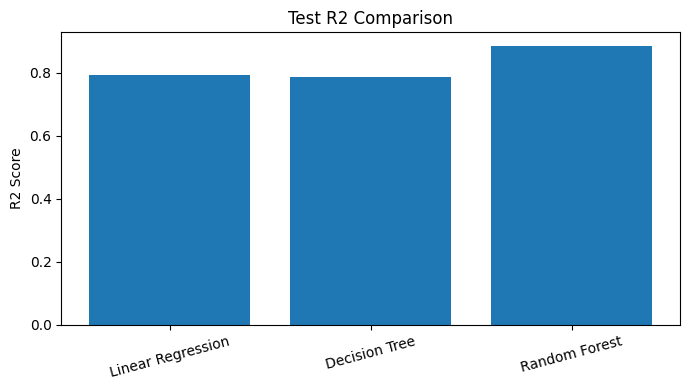

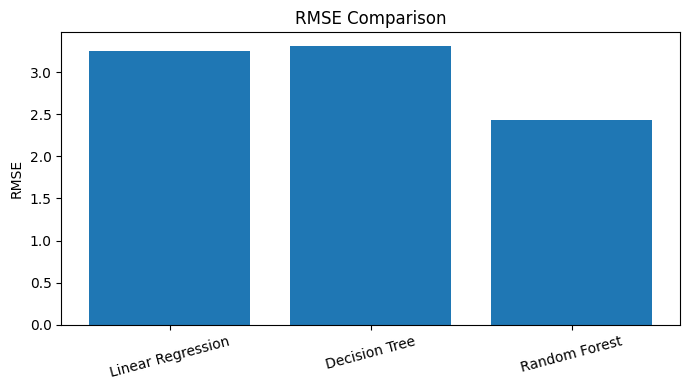

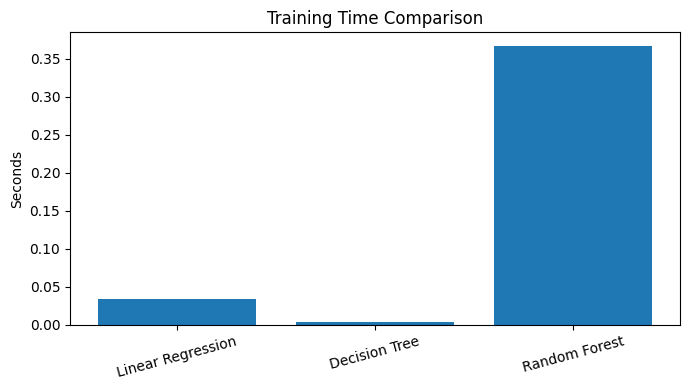

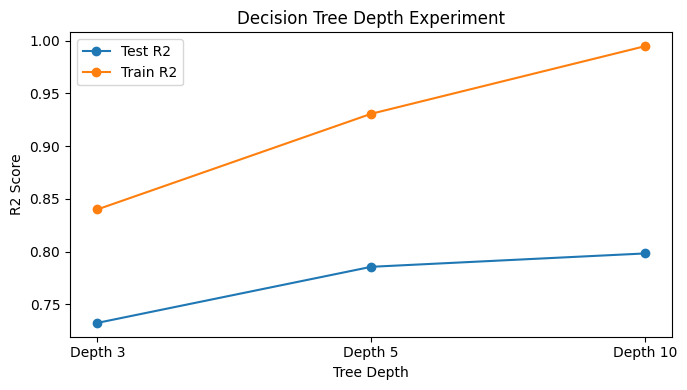

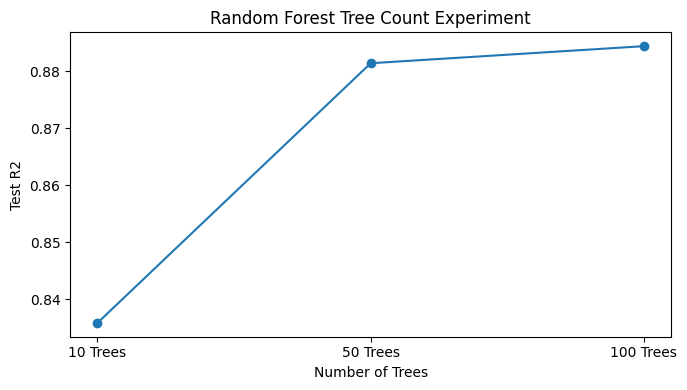

In [8]:
# Baseline Test R2
plt.figure(figsize=(7, 4))
plt.bar(results_df["Model"], results_df["Test R2"])
plt.title("Test R2 Comparison")
plt.ylabel("R2 Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Baseline RMSE
plt.figure(figsize=(7, 4))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Training time
plt.figure(figsize=(7, 4))
plt.bar(
    results_df["Model"],
    results_df["Training Time (sec)"]
)
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Decision Tree depth experiment
tree_experiments = experiment_df[
    experiment_df["Model"] == "Decision Tree"
]

plt.figure(figsize=(7, 4))
plt.plot(
    tree_experiments["Condition"],
    tree_experiments["Test R2"],
    marker="o",
    label="Test R2"
)
plt.plot(
    tree_experiments["Condition"],
    tree_experiments["Train R2"],
    marker="o",
    label="Train R2"
)
plt.title("Decision Tree Depth Experiment")
plt.xlabel("Tree Depth")
plt.ylabel("R2 Score")
plt.legend()
plt.tight_layout()
plt.show()

# Random Forest tree count experiment
forest_experiments = experiment_df[
    experiment_df["Model"] == "Random Forest"
]

plt.figure(figsize=(7, 4))
plt.plot(
    forest_experiments["Condition"],
    forest_experiments["Test R2"],
    marker="o"
)
plt.title("Random Forest Tree Count Experiment")
plt.xlabel("Number of Trees")
plt.ylabel("Test R2")
plt.tight_layout()
plt.show()

# Conclusion

This investigation examined the research question:

> **When should a simpler model be preferred to a more complex model?**

The experiments compared Linear Regression, Decision Tree Regression, and Random Forest Regression in terms of predictive performance, generalization, model complexity, interpretability, and computational cost.

The results showed that **Random Forest achieved the highest test R² (0.8844) and the lowest RMSE (2.4288)** among the baseline models. However, increasing model complexity did not always result in a proportional improvement in generalization. For the Decision Tree, increasing the depth increased training R² from **0.8401 to 0.9948**, while the cross-validation R² decreased from **0.7994 at depth 5 to 0.7808 at depth 10**, providing evidence of overfitting at higher complexity.

For Random Forest, increasing the number of trees from **10 to 50** improved test R² from **0.8358 to 0.8814**. However, increasing the number from **50 to 100** produced only a small improvement to **0.8844**, while training time increased. This demonstrates diminishing returns from increasing model complexity.

Therefore, the results show that a model should not be selected based only on its highest predictive performance. A simpler model may be preferred when its performance is sufficient and its advantages in **interpretability, computational efficiency, and simpler model structure** are important. A more complex model may be justified when the improvement in predictive performance is significant enough to meet the requirements of the application.

Overall, the investigation demonstrates that **model selection involves a trade-off between performance, generalization, complexity, interpretability, and computational cost**. The conclusions are based on the Auto MPG dataset and the experimental conditions used in this investigation, so further experiments on other datasets would be required to determine whether the same behaviour generalizes more broadly.